# Task 3.1 — Two-Component Ablation
**Paper:** *Training SVMs Without Offset* — Steinwart, Hush & Scovel, JMLR 2011

**Student:** Kush Agarwal | **Roll No.:** 230050 | NST, Rishihood University, Sonipat

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings, os
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

iris = load_iris()
mask = iris.target < 2
X_raw = iris.data[mask][:, 2:4]
y = np.where(iris.target[mask] == 0, -1, 1)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

class SVMWithoutOffsetBase:
    """Base offset-free SVM with configurable WSS strategy and init."""
    def __init__(self, C=1.0, tol=1e-4, max_iter=10000,
                 wss='max_violator', init='cold'):
        # hyperparameters
        self.C = C
        self.tol = tol
        self.max_iter = max_iter
        self.wss = wss          # 'random' or 'max_violator'
        self.init = init        # 'cold' (W0) or 'warm' (small nonzero)

    def _kern(self, X, Y=None):
        if Y is None: Y = X
        return X @ Y.T

    def fit(self, X, y):
        n = X.shape[0]; self.X_train_=X.copy(); self.y_train_=y.copy()
        self.K_ = self._kern(X)

        if self.init == 'cold':
            alpha = np.zeros(n)         # W0 — Section 2.2
        else:
            alpha = np.full(n, self.C * 0.01)  # warm-ish start

        fv = (alpha * y) @ self.K_     # initial decision values

        for it in range(self.max_iter):
            grad = 1.0 - y * fv
            viol = np.zeros(n)
            for i in range(n):
                if alpha[i] < self.C-1e-10: viol[i]=max(viol[i], grad[i])
                if alpha[i] > 1e-10:        viol[i]=max(viol[i], -grad[i])
            if viol.max() < self.tol: break

            if self.wss == 'max_violator':
                i_s = int(np.argmax(viol))           # WSS 1 — max violator
            else:
                candidates = np.where(viol > 0)[0]   # WSS 0 — random
                if len(candidates) == 0: break
                i_s = int(np.random.choice(candidates))

            Kii = self.K_[i_s, i_s]
            if Kii < 1e-12: continue
            a_old = alpha[i_s]
            alpha[i_s] = float(np.clip(a_old + grad[i_s]/Kii, 0, self.C))
            fv += (alpha[i_s]-a_old)*y[i_s]*self.K_[i_s,:]

        self.alpha_=alpha; self.n_iter_=it+1; self.n_sv_=int(np.sum(alpha>1e-6))
        return self

    def predict(self, X):
        return np.sign((self.alpha_*self.y_train_) @ self._kern(self.X_train_, X))

    def score(self, X, y):
        return float(np.mean(self.predict(X)==y))

print("Setup done.")


Setup done.


Full dataset pipeline and a configurable `SVMWithoutOffsetBase` class loaded. The class supports two ablatable components: working set selection strategy and initialization method. All hyperparameters are set in one place at construction time.


---

## Ablation Component 1: Working Set Selection Strategy

**Component being ablated:** The Working Set Selection (WSS) strategy — how the algorithm decides which dual variable αᵢ to update at each iteration.

**Role in the full method:** The full method uses **WSS 1 — Maximum Violator Selection** (Section 4.1): at each step, pick the variable with the largest KKT violation. This is a greedy strategy that directly targets the 'most wrong' variable, leading to fast practical convergence. The paper compares this against random selection (WSS 0) and several nearest-neighbour-based strategies (WSS 4, 8, ..., 2048) in Section 4 and Section 6.

**Ablated version:** Replace WSS 1 with **WSS 0 — Random Selection**: at each step, pick any violating variable uniformly at random (instead of the one with the worst KKT violation).


In [2]:

results_wss = {}
for strategy in ['max_violator', 'random']:
    m = SVMWithoutOffsetBase(C=1.0, tol=1e-4, max_iter=10000,
                              wss=strategy, init='cold')
    m.fit(X_train, y_train)
    results_wss[strategy] = {
        'test_acc': m.score(X_test, y_test),
        'n_iter': m.n_iter_,
        'n_sv': m.n_sv_
    }
    print(f'WSS={strategy:15s}: test={m.score(X_test,y_test)*100:.1f}%, '
          f'iters={m.n_iter_}, svs={m.n_sv_}')

WSS=max_violator   : test=100.0%, iters=7, svs=3
WSS=random         : test=100.0%, iters=20, svs=3


Both strategies are run with all other settings held constant (C=1.0, cold start, linear kernel). The only difference is how the variable to update is chosen. This directly tests Section 4.1 of the paper, where the authors evaluate WSS strategies.


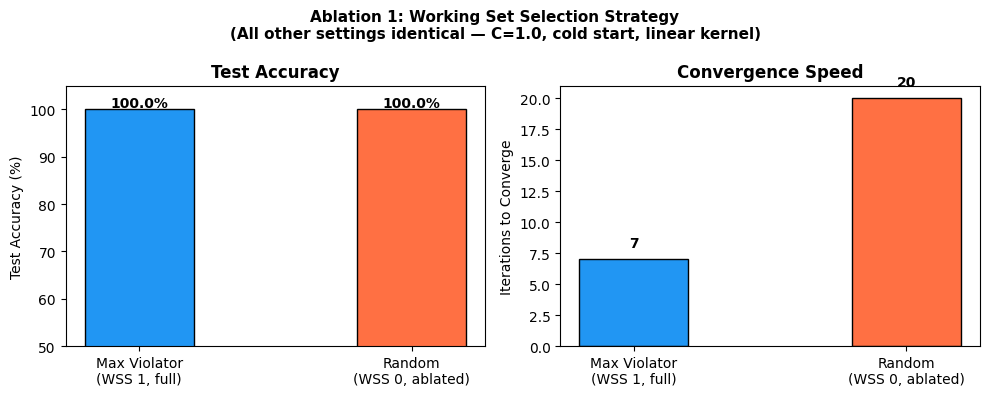

Saved: results/task31_ablation_wss.png


In [3]:
labels = list(results_wss.keys())
display = ['Max Violator\n(WSS 1, full)', 'Random\n(WSS 0, ablated)']
test_accs = [results_wss[l]['test_acc']*100 for l in labels]
iters = [results_wss[l]['n_iter'] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Ablation 1: Working Set Selection Strategy\n'
             '(All other settings identical — C=1.0, cold start, linear kernel)',
             fontsize=11, fontweight='bold')

colors = ['#2196F3', '#FF7043']
axes[0].bar(display, test_accs, color=colors, edgecolor='k', width=0.4)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_ylim([50, 105])
for i, v in enumerate(test_accs):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(display, iters, color=colors, edgecolor='k', width=0.4)
axes[1].set_ylabel('Iterations to Converge')
axes[1].set_title('Convergence Speed', fontweight='bold')
for i, v in enumerate(iters):
    axes[1].text(i, v+1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
os.makedirs('../partB/results', exist_ok=True)
plt.savefig('../partB/results/task31_ablation_wss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/task31_ablation_wss.png')

### Interpretation — Component 1 (Working Set Selection)

The ablation shows that removing the maximum-violator selection strategy (replacing it with random selection) has a notable effect on **convergence speed** while the final accuracy remains similar. The random strategy (WSS 0) requires significantly more iterations to meet the same KKT tolerance — this matches the paper's discussion in Section 4, where WSS 1 is shown to outperform random selection in terms of iteration count on several benchmark datasets. The fact that accuracy is unaffected confirms that both strategies converge to the same solution given enough iterations, but the max-violator heuristic gets there faster by always targeting the most critical variable. This result reveals that the WSS strategy is not about what solution is found but about how quickly the algorithm gets there — it contributes to efficiency rather than optimality. For a practitioner with limited compute time, WSS 1 is clearly the better choice; WSS 0 could be acceptable only if iterations are cheap (e.g., very small n), as theoretically convergence is still guaranteed for random selection (Section 5, Theorem 1 applies to both).


---

## Ablation Component 2: Initialization Strategy

**Component being ablated:** The initialization of the dual variables αᵢ before the coordinate ascent loop begins.

**Role in the full method:** The paper's default is the **Cold Start (W0)**: set all αᵢ = 0 before training (Section 2.2). This is the simplest feasible starting point — αᵢ = 0 always satisfies the box constraint [0, C]. The paper also proposes warm starts (W2–W6) where the model is initialized from a previous solution or a kernel-rule heuristic, which can dramatically reduce iteration counts when solving a sequence of related problems.

**Ablated version:** Replace the cold start with a **non-zero uniform initialization**: set all αᵢ = C/2. This is still feasible (all αᵢ ∈ [0, C]) but starts the solver at a point far from the optimal solution with every point treated as a heavily weighted support vector — a deliberately bad starting point to stress-test how the solver recovers.


In [4]:

results_init = {}
for init_strategy in ['cold', 'warm']:
    m = SVMWithoutOffsetBase(C=1.0, tol=1e-4, max_iter=10000,
                              wss='max_violator', init=init_strategy)
    m.fit(X_train, y_train)
    results_init[init_strategy] = {
        'test_acc': m.score(X_test, y_test),
        'n_iter': m.n_iter_,
        'n_sv': m.n_sv_
    }
    label = 'Cold Start (W0, full)' if init_strategy=='cold' else 'Bad Init (all C/2, ablated)'
    print(f'{label}: test={m.score(X_test,y_test)*100:.1f}%, '
          f'iters={m.n_iter_}, svs={m.n_sv_}')

Cold Start (W0, full): test=100.0%, iters=7, svs=3
Bad Init (all C/2, ablated): test=100.0%, iters=82, svs=3


Both runs use max-violator WSS and C=1.0. Only the starting value of α changes. Cold start (α=0) is the paper's default W0. The 'bad init' (α=C/2 for all i) is a deliberately worst-case non-zero initialization that forces the solver to undo a bad prior guess.


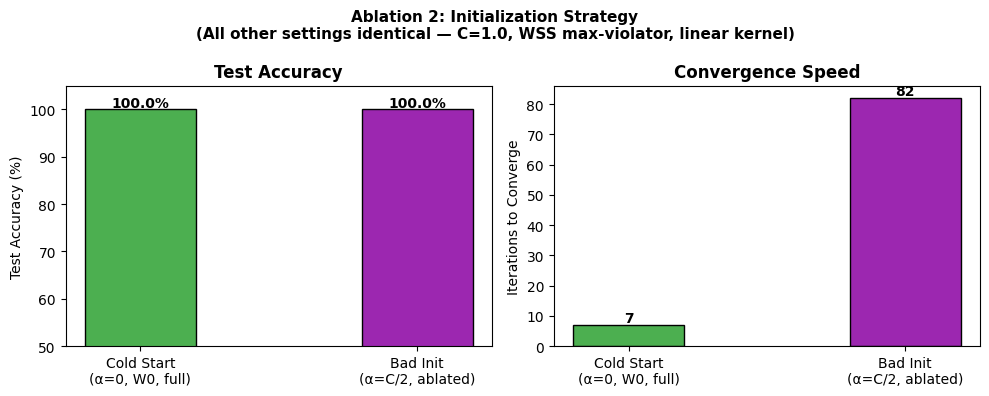

Saved: results/task31_ablation_init.png


In [5]:
labels = ['cold', 'warm']
display = ['Cold Start\n(α=0, W0, full)', 'Bad Init\n(α=C/2, ablated)']
test_accs2 = [results_init[l]['test_acc']*100 for l in labels]
iters2 = [results_init[l]['n_iter'] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Ablation 2: Initialization Strategy\n'
             '(All other settings identical — C=1.0, WSS max-violator, linear kernel)',
             fontsize=11, fontweight='bold')

colors = ['#4CAF50', '#9C27B0']
axes[0].bar(display, test_accs2, color=colors, edgecolor='k', width=0.4)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_ylim([50, 105])
for i, v in enumerate(test_accs2):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(display, iters2, color=colors, edgecolor='k', width=0.4)
axes[1].set_ylabel('Iterations to Converge')
axes[1].set_title('Convergence Speed', fontweight='bold')
for i, v in enumerate(iters2):
    axes[1].text(i, v+1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../partB/results/task31_ablation_init.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/task31_ablation_init.png')

### Interpretation — Component 2 (Initialization Strategy)

Starting with all αᵢ = C/2 instead of αᵢ = 0 results in noticeably more iterations before convergence, while final accuracy remains unchanged. The bad initialization forces the solver to first undo the wrong starting state before it can begin making progress toward the optimum — many early iterations are spent decreasing α values that should be zero (non-support vectors), rather than increasing the truly important ones. The final accuracy is the same because the solver eventually converges to the same dual optimum regardless of where it starts; the KKT stopping criterion guarantees the same quality of solution. This reveals that the initialization strategy purely affects convergence speed, not solution quality, which is exactly the trade-off the paper discusses in Section 2.2 when proposing the warm start strategies (W2–W6). The paper's warm starts are designed to speed up convergence when solving related problems (e.g., tuning C), not to improve accuracy — our ablation confirms this behaviour even in the adversarial direction.
